In [30]:
import few 
from few.trajectory.inspiral import EMRIInspiral
from few.waveform import GenerateEMRIWaveform
from few.trajectory.ode import KerrEccEqFlux
from few.utils.geodesic import get_separatrix

In [ ]:
from mew import KerrCircEqFluxScalar

In [8]:
p_buffer = 0.01

traj_Kerr_GR = EMRIInspiral(func=KerrEccEqFlux)
traj_Kerr_Scalar = EMRIInspiral(func=KerrCircEqFluxScalar, integrate_constants_of_motion=False)

In [27]:
M = 1e6
mu = 10
a = 0.9
e0 = 0.0
x_I0 = 1.0
dt = 1.0
Tobs = 4 

print("M = ", M)
print("mu = ", mu)
print("a = ", a)
print("e0 = ", e0)
print("x_I0 = ", x_I0)
print("dt = ", dt)
print("Tobs = ", Tobs)

p_sep = get_separatrix(a, e0, x_I0)
print(f"Separatrix: {p_sep}")

t_back_GR, p_back_GR, e_back_GR, x_back_GR, Phi_phi_back_GR, Phi_r_back_GR, Phi_theta_back_GR = traj_Kerr_GR(M, mu, a, p_sep + p_buffer, e0, x_I0 , dt=dt, T=Tobs, integrate_backwards=True)
p0 = p_back_GR[-1]
print("p0 with GR model = ", p0)


d = 0.0
t_back_s0, p_back_s0, e_back_s0, x_back_s0, Phi_phi_back_s0, Phi_r_back_s0, Phi_theta_back_s0 = traj_Kerr_Scalar(M, mu, a, p_sep + p_buffer, e0, x_I0, d, dt=dt, T=Tobs, integrate_backwards=True)
p0 = p_back_s0[-1]
print(f"p0 with Scalar model when d = {d}: {p0}")

d = 0.3
t_back_s03, p_back_s03, e_back_s03, x_back_s03, Phi_phi_back_s03, Phi_r_back_s03, Phi_theta_back_s03 = traj_Kerr_Scalar(M, mu, a, p_sep + p_buffer, e0, x_I0, d, dt=dt, T=Tobs, integrate_backwards=True)

p0 = p_back_s03[-1]
print(f"p0 with Scalar model when d = {d}: {p0}")

M =  1000000.0
mu =  10
a =  0.9
e0 =  0.0
x_I0 =  1.0
dt =  1.0
Tobs =  4
Separatrix: 2.320883041761887
p0 with GR model =  10.22987662564212
p0 with Scalar model when d = 0.0: 10.22987662564212
p0 with Scalar model when d = 0.3: 10.314896809005402


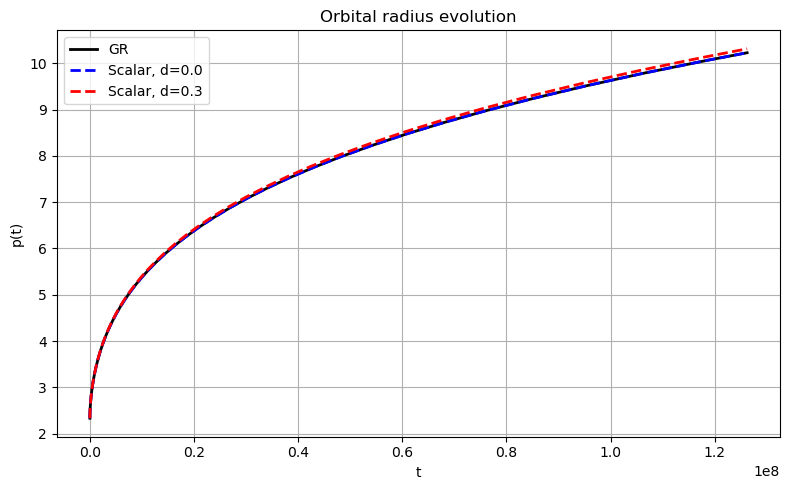

In [28]:
import matplotlib.pyplot as plt

# --- Plot p(t) for GR and Scalar models ---

plt.figure(figsize=(8,5))

# GR model
plt.plot(t_back_GR, p_back_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
d = 0.0
plt.plot(t_back_s0, p_back_s0, label=f"Scalar, d={d}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.3
d = 0.3
plt.plot(t_back_s03, p_back_s03, label=f"Scalar, d={d}", linestyle="--", color="red", linewidth=2)

# Labels
plt.xlabel("t")
plt.ylabel("p(t)")
plt.title("Orbital radius evolution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

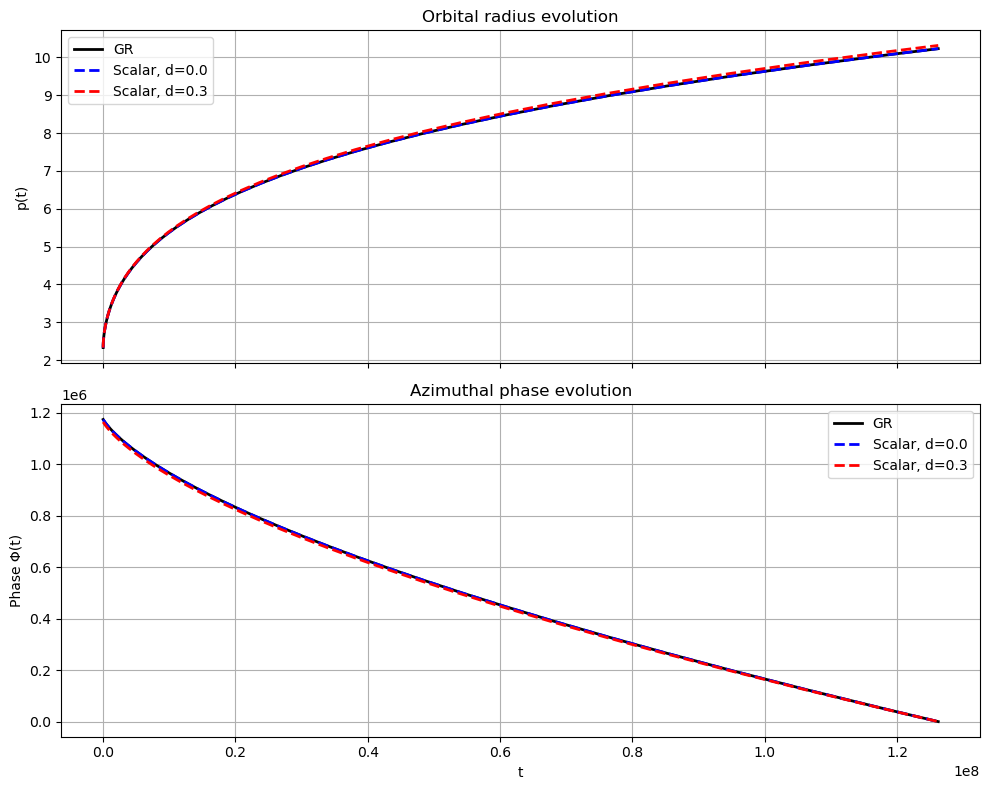

In [29]:
import matplotlib.pyplot as plt

# --- Create figure with 2 subplots ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Plot p(t) in the first subplot ---
ax1 = axes[0]

# GR model
ax1.plot(t_back_GR, p_back_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
d = 0.0
ax1.plot(t_back_s0, p_back_s0, label=f"Scalar, d={d}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.3
d = 0.3
ax1.plot(t_back_s03, p_back_s03, label=f"Scalar, d={d}", linestyle="--", color="red", linewidth=2)

ax1.set_ylabel("p(t)")
ax1.set_title("Orbital radius evolution")
ax1.legend()
ax1.grid(True)

# --- Plot phase Φ(t) in the second subplot ---
ax2 = axes[1]

# GR model
ax2.plot(t_back_GR, Phi_phi_back_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
ax2.plot(t_back_s0, Phi_phi_back_s0, label=f"Scalar, d={0.0}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.3
ax2.plot(t_back_s03, Phi_phi_back_s03, label=f"Scalar, d={0.3}", linestyle="--", color="red", linewidth=2)

ax2.set_xlabel("t")
ax2.set_ylabel("Phase Φ(t)")
ax2.set_title("Azimuthal phase evolution")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [31]:
M = 1e6
mu = 10
a = 0.9
e0 = 0.0
x_I0 = 1.0
dt = 1.0
Tobs = 4.0 

print("M = ", M)
print("mu = ", mu)
print("a = ", a)
print("e0 = ", e0)
print("x_I0 = ", x_I0)
print("dt = ", dt)
print("Tobs = ", Tobs)

p_sep = get_separatrix(a, e0, x_I0)
print(f"Separatrix: {p_sep}")

p0 = 8.0
t_GR, p_GR, e_GR, x_GR, Phi_phi_GR, Phi_r_GR, Phi_theta_GR = traj_Kerr_GR(M, mu, a, p0, e0, x_I0 , dt=dt, T=Tobs, integrate_backwards=False)
p_fin = p[-1]
print("p_fin with GR model = ", p_fin)

d = 0.0
t_s0, p_s0, e_s0, x_s0, Phi_phi_s0, Phi_r_s0, Phi_theta_s0 = traj_Kerr_Scalar(M, mu, a, p0, e0, x_I0 , d, dt=dt, T=Tobs, integrate_backwards=False)
p_fin = p_s0[-1]
print(f"p_fin with Scalar model when d = {d}: {p_fin}")

d = 0.3
t_s03, p_s03, e_s03, x_s03, Phi_phi_s03, Phi_r_s03, Phi_theta_s03 = traj_Kerr_Scalar(M, mu, a, p0, e0, x_I0 , d, dt=dt, T=Tobs, integrate_backwards=False)
p_fin = p_s03[-1]
print(f"p_fin with Scalar model when d = {d}: {p_fin}")

M =  1000000.0
mu =  10
a =  0.9
e0 =  0.0
x_I0 =  1.0
dt =  1.0
Tobs =  4.0
Separatrix: 2.320883041761887
p_fin with GR model =  197.99981399366536
p_fin with Scalar model when d = 0.0: 2.322883041761679
p_fin with Scalar model when d = 0.3: 2.322883041803203


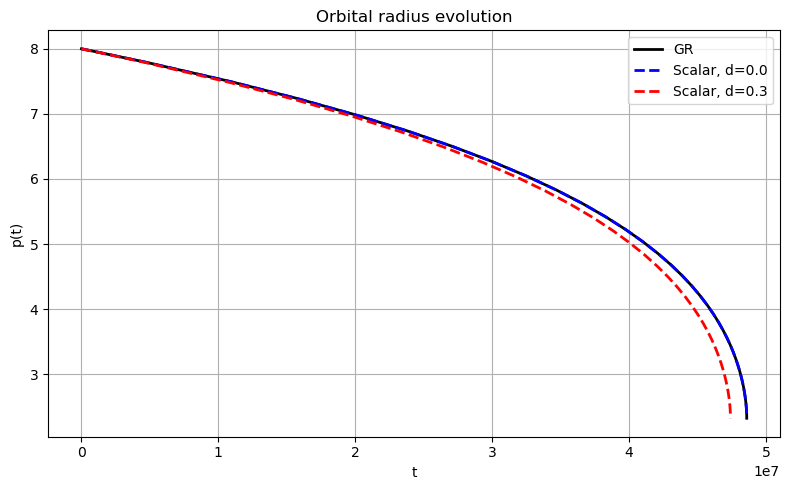

In [26]:
# --- Plot p(t) for GR and Scalar models ---

plt.figure(figsize=(8,5))

# GR model
plt.plot(t_GR, p_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
d = 0.0
plt.plot(t_s0, p_s0, label=f"Scalar, d={d}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.3
d = 0.3
plt.plot(t_s03, p_s03, label=f"Scalar, d={d}", linestyle="--", color="red", linewidth=2)

# Labels
plt.xlabel("t")
plt.ylabel("p(t)")
plt.title("Orbital radius evolution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

AttributeError: 'Axes' object has no attribute 'logplot'

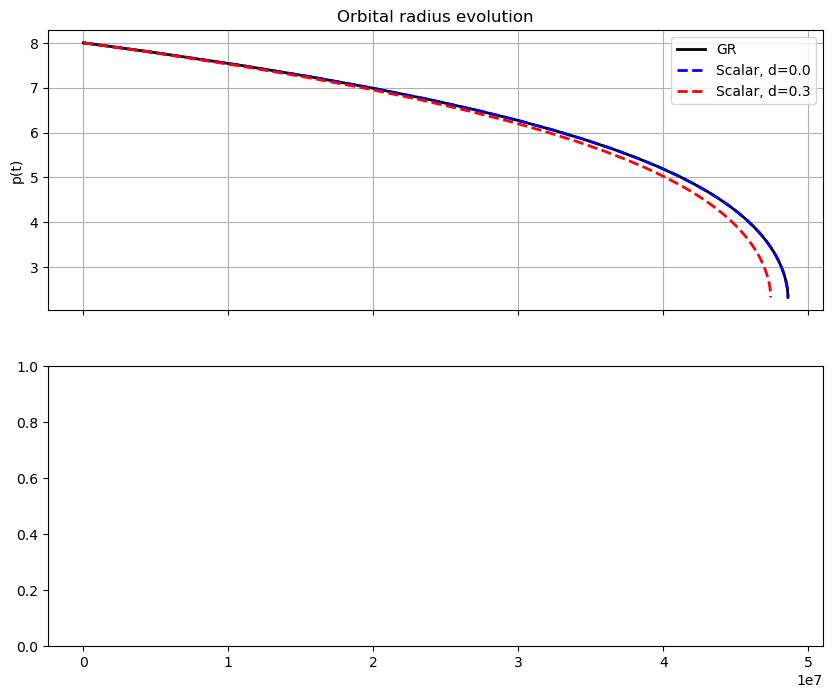

In [ ]:
import matplotlib.pyplot as plt

# --- Create figure with 2 subplots ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Plot p(t) in the first subplot ---
ax1 = axes[0]

# GR model
ax1.plot(t_GR, p_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
d = 0.0
ax1.plot(t_s0, p_s0, label=f"Scalar, d={d}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.3
d = 0.3
ax1.plot(t_s03, p_s03, label=f"Scalar, d={d}", linestyle="--", color="red", linewidth=2)

ax1.set_ylabel("p(t)")
ax1.set_title("Orbital radius evolution")
ax1.legend()
ax1.grid(True)

# --- Plot phase Φ(t) in the second subplot ---
ax2 = axes[1]

# GR model
ax2.plot(t_GR, Phi_phi_GR, label="GR", color="black", linewidth=2)

# Scalar model d = 0
ax2.plot(t_s0, Phi_phi_s0, label=f"Scalar, d={0.0}", linestyle="--", color="blue", linewidth=2)

# Scalar model d = 0.3
ax2.plot(t_s03, Phi_phi_s03, label=f"Scalar, d={0.3}", linestyle="--", color="red", linewidth=2)

ax2.set_xlabel("t")
ax2.set_ylabel("Phase Φ(t)")
ax2.set_title("Azimuthal phase evolution")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [18]:
d = 0.3
p0 = 10.0
e0 = 0.3
t, p, e, x, Phi_phi, Phi_r, Phi_theta = traj_Kerr_Scalar(M, mu, a, p0, e0, x_I0 , d, dt=dt, T=Tobs, integrate_backwards=False)
p_fin = p[-1]
print(f"p_fin with Scalar model when d = {d}: {p_fin}")

ValueError: Eccentricity e must be zero for circular orbits.

In [19]:
d = 0.3
p0 = 10.0
x_I0 = 1.1
t, p, e, x, Phi_phi, Phi_r, Phi_theta = traj_Kerr_Scalar(M, mu, a, p0, e0, x_I0 , d, dt=dt, T=Tobs, integrate_backwards=False)
p_fin = p[-1]
print(f"p_fin with Scalar model when d = {d}: {p_fin}")

ValueError: Interpolation: x out of bounds. Must be either 1 or -1.